In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import subprocess

process = subprocess.run(['apt-get', 'update'], capture_output=True, text=True)
print(process.stdout)
print(process.stderr)

process = subprocess.run(['apt-get', 'install', '-y', 'unrar-free'], capture_output=True, text=True)
print(process.stdout)
print(process.stderr)

print("unrar-free package installation attempted.")

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

Reading package l

In [ ]:
import os
import subprocess

temp_dir = '/content/temp_extracted_data'
os.makedirs(temp_dir, exist_ok=True)
print(f"Created temporary directory: {temp_dir}")

rar_archive_path = '/content/drive/MyDrive/Dataset_Part1.rar'

process = subprocess.run(['unrar', 'x', '-o+', '-r', rar_archive_path, temp_dir], capture_output=True, text=True)
print(process.stdout)
print(process.stderr)

print(f"RAR archive extraction attempted to {temp_dir}.")

Created temporary directory: /content/temp_extracted_data

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/Dataset_Part1.rar

Creating    /content/temp_extracted_data/Dataset_Part1                OK
Creating    /content/temp_extracted_data/Dataset_Part1/1              OK
Extracting  /content/temp_extracted_data/Dataset_Part1/1/1.JPG             0%  OK 
Extracting  /content/temp_extracted_data/Dataset_Part1/1/2.JPG             0%  OK 
Extracting  /content/temp_extracted_data/Dataset_Part1/1/3.JPG             0%  OK 
Extracting  /content/temp_extracted_data/Dataset_Part1/1/4.JPG             0%  OK 
Extracting  /content/temp_extracted_data/Dataset_Part1/1/5.JPG             0%  OK 
Extracting  /content/temp_extracted_data/Dataset_Part1/1/6.JPG             0%  OK 
Extracting  /content/temp_extracted_data/Dataset_Part1/1/7.JPG             0%  OK 
Creating    /conte

In [ ]:
import os

train_dir = '/content/data/SICE_Part1_split/train'
val_dir = '/content/data/SICE_Part1_split/validation'

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

print(f"Created training directory: {train_dir}")
print(f"Created validation directory: {val_dir}")

Created training directory: /content/data/SICE_Part1_split/train
Created validation directory: /content/data/SICE_Part1_split/validation


In [ ]:
import os
import glob
import random
import shutil

source_dir = '/content/temp_extracted_data/Dataset_Part1'
train_dir = '/content/data/SICE_Part1_split/train'
val_dir = '/content/data/SICE_Part1_split/validation'

all_images = glob.glob(os.path.join(source_dir, '**', '*.JPG'), recursive=True)

print(f"Found {len(all_images)} images in total.")

random.shuffle(all_images)

# Calculate the split point (80% for training, 20% for validation)
total_images = len(all_images)
train_split_idx = int(0.8 * total_images)

train_images = all_images[:train_split_idx]
val_images = all_images[train_split_idx:]

print(f"Splitting into {len(train_images)} training images and {len(val_images)} validation images.")

for img_path in train_images:
    shutil.copy(img_path, train_dir)

for img_path in val_images:
    shutil.copy(img_path, val_dir)

print(f"Moved {len(train_images)} images to {train_dir}")
print(f"Moved {len(val_images)} images to {val_dir}")

Found 3381 images in total.
Splitting into 2704 training images and 677 validation images.
Moved 2704 images to /content/data/SICE_Part1_split/train
Moved 677 images to /content/data/SICE_Part1_split/validation


In [ ]:
# -------------------------
# IMPORTS
# -------------------------
import os
import glob
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as T
from PIL import Image

random.seed(1143)

# -------------------------
# DATASET
# -------------------------
resize_and_normalize = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])

def populate_data(training_img_path):
    return glob.glob(os.path.join(training_img_path, "**", "*.JPG"), recursive=True)

class training_image_loader(data.Dataset):
    def __init__(self, training_img_path):

        self.data_list = populate_data(training_img_path)
        random.shuffle(self.data_list)
        print("Total training examples:", len(self.data_list))

    def __getitem__(self, index):
        img = Image.open(self.data_list[index]).convert("RGB")
        return resize_and_normalize(img)

    def __len__(self):
        return len(self.data_list)


# -------------------------
# NETWORK
# -------------------------
class dce_net(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)

        number_f = 32
        self.conv1 = nn.Conv2d(3, number_f, 3, 1, 1)
        self.conv2 = nn.Conv2d(number_f, number_f, 3, 1, 1)
        self.conv3 = nn.Conv2d(number_f, number_f, 3, 1, 1)
        self.conv4 = nn.Conv2d(number_f, number_f, 3, 1, 1)
        self.conv5 = nn.Conv2d(number_f * 2, number_f, 3, 1, 1)
        self.conv6 = nn.Conv2d(number_f * 2, number_f, 3, 1, 1)
        self.conv7 = nn.Conv2d(number_f * 2, 24, 3, 1, 1)

    def forward(self, x):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))
        x4 = self.relu(self.conv4(x3))

        x5 = self.relu(self.conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.conv6(torch.cat([x2, x5], 1)))

        x_final = self.relu(self.conv7(torch.cat([x1, x6], 1)))

        r_list = torch.split(x_final, 3, dim=1)
        r = torch.cat(r_list, dim=1)

        x_out = x
        for i in range(8):
            x_out = x_out + r_list[i] * (x_out * x_out - x_out)

        return x_out, x_out, r   # (enhanced_image_8, enhanced_image_4, r)


# -------------------------
# LOSSES
# -------------------------
class L_color(nn.Module):
    def forward(self, x):
        mean_ch = torch.mean(x, [2, 3], keepdim=True)
        mr, mg, mb = torch.split(mean_ch, 1, dim=1)
        return torch.sqrt((mr-mg)**2 + (mr-mb)**2 + (mb-mg)**2)


class L_spa(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.AvgPool2d(4)

        k_left   = torch.tensor([[0,0,0],[-1,1,0],[0,0,0]], dtype=torch.float32).reshape(1,1,3,3)
        k_right  = torch.tensor([[0,0,0],[0,1,-1],[0,0,0]], dtype=torch.float32).reshape(1,1,3,3)
        k_top    = torch.tensor([[0,-1,0],[0,1,0],[0,0,0]], dtype=torch.float32).reshape(1,1,3,3)
        k_bottom = torch.tensor([[0,0,0],[0,1,0],[0,-1,0]], dtype=torch.float32).reshape(1,1,3,3)

        self.l = nn.Parameter(k_left,  requires_grad=False)
        self.r = nn.Parameter(k_right, requires_grad=False)
        self.t = nn.Parameter(k_top,   requires_grad=False)
        self.b = nn.Parameter(k_bottom,requires_grad=False)

    def forward(self, original, enhanced):
        o = self.pool(original.mean(1, keepdim=True))
        e = self.pool(enhanced.mean(1, keepdim=True))

        return ((F.conv2d(e, self.l) - F.conv2d(o, self.l))**2 +
                (F.conv2d(e, self.r) - F.conv2d(o, self.r))**2 +
                (F.conv2d(e, self.t) - F.conv2d(o, self.t))**2 +
                (F.conv2d(e, self.b) - F.conv2d(o, self.b))**2)


class L_exp(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.AvgPool2d(16)
        self.mean_val = 0.6

    def forward(self, x):
        x_gray = self.pool(x.mean(1, keepdim=True))
        return torch.mean((x_gray - self.mean_val) ** 2)


class L_ill(nn.Module):
    def forward(self, A):
        b, c, h, w = A.shape
        loss_x = ((A[:, :, 1:, :] - A[:, :, :-1, :]) ** 2).sum() / ((h - 1) * w)
        loss_y = ((A[:, :, :, 1:] - A[:, :, :, :-1]) ** 2).sum() / ((w - 1) * h)
        return (loss_x + loss_y) / b


# -------------------------
# TRAIN LOOP
# -------------------------
def train(config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    net = dce_net().to(device)

    if config["load_pretrain"]:
        net.load_state_dict(torch.load(config["pretrain_dir"]))

    train_loader = torch.utils.data.DataLoader(
        training_image_loader(config["train_data_path"]),
        batch_size=config["train_batch_size"], shuffle=True
    )

    Lc = L_color().to(device)
    Ls = L_spa().to(device)
    Le = L_exp().to(device)
    Li = L_ill().to(device)

    optim = torch.optim.Adam(net.parameters(), lr=config["lr"])

    net.train()
    for epoch in range(config["num_epochs"]):
        print("Epoch:", epoch)
        for i, img_low in enumerate(train_loader):

            img_low = img_low.to(device)

            out8, out4, A = net(img_low)

            loss = (
                200 * Li(A) +
                torch.mean(Ls(out8, img_low)) +
                5 * torch.mean(Lc(out8)) +
                10 * torch.mean(Le(out8))
            )

            optim.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), config["grad_clip_norm"])
            optim.step()

            if (i + 1) % config["display_iter"] == 0:
                print("Iter:", i+1, "Loss:", loss.item())


# -------------------------
# CONFIG (NO ARGPARSE)
# -------------------------
config = {
    "train_data_path": "/content/data/SICE_Part1_split/train",
    "val_data_path": "/content/data/SICE_Part1_split/validation",
    "lr": 0.0001,
    "weight_decay": 0.0001,
    "grad_clip_norm": 0.1,
    "num_epochs": 100,
    "train_batch_size": 4,
    "display_iter": 10,
    "load_pretrain": False,
    "pretrain_dir": "/content/snapshots/Epoch99.pth"
}


# -------------------------
# START TRAINING
# -------------------------
train(config)

Total training examples: 298
Epoch: 0
Iter: 10 Loss: 1.7435886859893799
Iter: 20 Loss: 1.2024813890457153
Iter: 30 Loss: 1.4145781993865967
Iter: 40 Loss: 1.1660196781158447
Iter: 50 Loss: 1.2495882511138916
Iter: 60 Loss: 1.3770109415054321
Iter: 70 Loss: 1.0764272212982178
Epoch: 1
Iter: 10 Loss: 1.0286613702774048
Iter: 20 Loss: 1.3290542364120483
Iter: 30 Loss: 1.5850532054901123
Iter: 40 Loss: 1.308081030845642
Iter: 50 Loss: 1.046120524406433
Iter: 60 Loss: 1.1702730655670166
Iter: 70 Loss: 0.9273860454559326
Epoch: 2
Iter: 10 Loss: 1.1299266815185547
Iter: 20 Loss: 1.2049987316131592
Iter: 30 Loss: 1.1478421688079834
Iter: 40 Loss: 1.2107315063476562
Iter: 50 Loss: 1.3181772232055664
Iter: 60 Loss: 1.4984897375106812
Iter: 70 Loss: 0.8296129107475281
Epoch: 3
Iter: 10 Loss: 1.1040278673171997
Iter: 20 Loss: 2.2140488624572754
Iter: 30 Loss: 1.346914529800415
Iter: 40 Loss: 1.2146623134613037
Iter: 50 Loss: 1.4344923496246338
Iter: 60 Loss: 1.3529642820358276
Iter: 70 Loss: 0.755

In [ ]:
import os

# Create the parent directory if it does not exist
os.makedirs('/content/snapshots', exist_ok=True)

torch.save(net.state_dict(), '/content/snapshots/Epoch99.pth')

Processing random image: /content/test.jpg


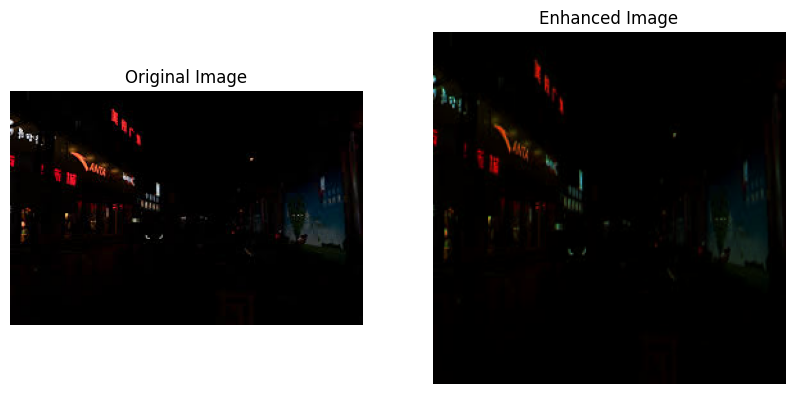

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T

# Re-define the resize_and_normalize transform and dce_net class
# as they are not available in the global scope of this cell.
resize_and_normalize = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])

class dce_net(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)

        number_f = 32
        self.conv1 = nn.Conv2d(3, number_f, 3, 1, 1)
        self.conv2 = nn.Conv2d(number_f, number_f, 3, 1, 1)
        self.conv3 = nn.Conv2d(number_f, number_f, 3, 1, 1)
        self.conv4 = nn.Conv2d(number_f, number_f, 3, 1, 1)
        self.conv5 = nn.Conv2d(number_f * 2, number_f, 3, 1, 1)
        self.conv6 = nn.Conv2d(number_f * 2, number_f, 3, 1, 1)
        self.conv7 = nn.Conv2d(number_f * 2, 24, 3, 1, 1)

    def forward(self, x):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))
        x4 = self.relu(self.conv4(x3))

        x5 = self.relu(self.conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.conv6(torch.cat([x2, x5], 1)))

        x_final = self.relu(torch.cat([x1, x6], 1))

        r_list = torch.split(x_final, 3, dim=1)
        r = torch.cat(r_list, dim=1)

        x_out = x
        for i in range(8):
            x_out = x_out + r_list[i] * (x_out * x_out - x_out)

        return x_out, x_out, r   # (enhanced_image_8, enhanced_image_4, r)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model again to make it available in this cell's scope.
net = dce_net().to(device)

# Load the saved weights
net.load_state_dict(torch.load('/content/snapshots/Epoch99.pth'))

net.eval() # Set the model to evaluation mode

# Get a random image from the validation set
random_img_path = "/content/test.jpg"
print(f"Processing random image: {random_img_path}")

# Load and preprocess the image
original_image = Image.open(random_img_path).convert("RGB")
input_tensor = resize_and_normalize(original_image).unsqueeze(0).to(device)

# Get enhanced output from the model
with torch.no_grad():
    enhanced_tensor, _, _ = net(input_tensor)

# Convert tensors back to PIL Images for display
enhanced_image = T.ToPILImage()(enhanced_tensor.squeeze(0).cpu())

# Display original and enhanced images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_image)
plt.title('Enhanced Image')
plt.axis('off')

plt.show()